In [2]:
import pandas as pd
import os

base = "/mnt/c/etri-lifelog/data/raw/data"

# 타겟 확인
train = pd.read_csv(f"{base}/ch2026_metrics_train.csv")
print("=== train shape ===")
print(train.shape)
print(train.head(3))
print(train.dtypes)
print(train.isnull().sum())

# 제출 형식 확인
sub = pd.read_csv(f"{base}/ch2026_submission_sample.csv")
print("\n=== submission sample ===")
print(sub.shape)
print(sub.head(3))

# 센서 폴더 확인
sensor_dir = f"{base}/ch2025_data_items"
print("\n=== 센서 파일 목록 ===")
for f in sorted(os.listdir(sensor_dir)):
    print(f)

=== train shape ===
(450, 10)
  subject_id  sleep_date lifelog_date  Q1  Q2  Q3  S1  S2  S3  S4
0       id01  2024-06-27   2024-06-26   0   0   0   0   0   1   0
1       id01  2024-06-28   2024-06-27   0   0   0   0   1   1   1
2       id01  2024-06-29   2024-06-28   1   0   0   1   1   1   1
subject_id      object
sleep_date      object
lifelog_date    object
Q1               int64
Q2               int64
Q3               int64
S1               int64
S2               int64
S3               int64
S4               int64
dtype: object
subject_id      0
sleep_date      0
lifelog_date    0
Q1              0
Q2              0
Q3              0
S1              0
S2              0
S3              0
S4              0
dtype: int64

=== submission sample ===
(250, 10)
  subject_id  sleep_date lifelog_date  Q1  Q2  Q3  S1  S2  S3  S4
0       id01  2024-07-31   2024-07-30   0   0   0   0   0   0   0
1       id01  2024-08-01   2024-07-31   0   0   0   0   0   0   0
2       id01  2024-08-02   2024-08

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path("/mnt/c/etri-lifelog/data/raw/data")
SENSOR_DIR = BASE / "ch2025_data_items"

train = pd.read_csv(BASE / "ch2026_metrics_train.csv")
sub   = pd.read_csv(BASE / "ch2026_submission_sample.csv")

train["lifelog_date"] = pd.to_datetime(train["lifelog_date"])
train["sleep_date"]   = pd.to_datetime(train["sleep_date"])

TARGETS = ["Q1","Q2","Q3","S1","S2","S3","S4"]
print(f"train: {train.shape}, test: {sub.shape}")
print(f"subjects: {train.subject_id.nunique()}")
print(f"기간: {train.lifelog_date.min()} ~ {train.lifelog_date.max()}")

train: (450, 10), test: (250, 10)
subjects: 10
기간: 2024-06-03 00:00:00 ~ 2024-11-14 00:00:00


count    10.000000
mean     45.000000
std       8.299933
min      33.000000
25%      41.000000
50%      46.000000
75%      48.750000
max      57.000000
dtype: float64


/tmp/ipykernel_9586/804312170.py:3: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/804312170.py:3: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/804312170.py:3: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout(); plt.show()
/home/rlawk/miniconda3/envs/etri/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/rlawk/miniconda3/envs/etri/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/rlawk/miniconda3/envs/etri/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL 

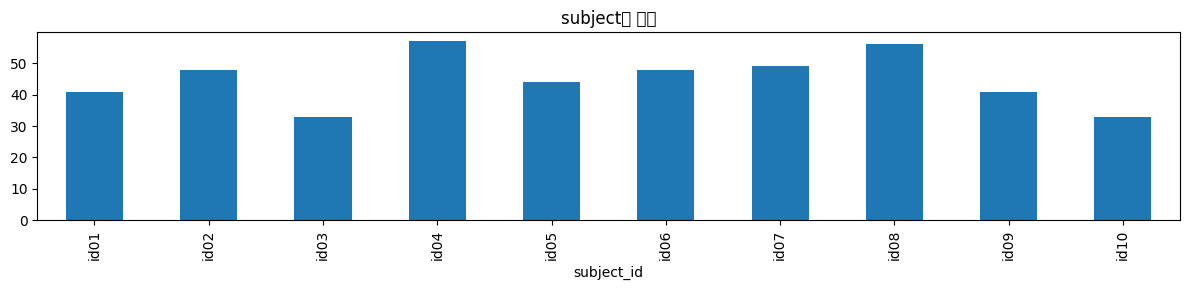

In [4]:
print(train.groupby("subject_id").size().describe())
train.groupby("subject_id").size().plot(kind="bar", figsize=(12,3), title="subject별 일수")
plt.tight_layout(); plt.show()

/tmp/ipykernel_9586/4002154526.py:10: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/4002154526.py:10: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/4002154526.py:10: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/4002154526.py:10: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout(); plt.show()
/home/rlawk/miniconda3/envs/etri/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/rlawk/miniconda3/envs/etri/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from current font.
  fig.canvas.print_fi

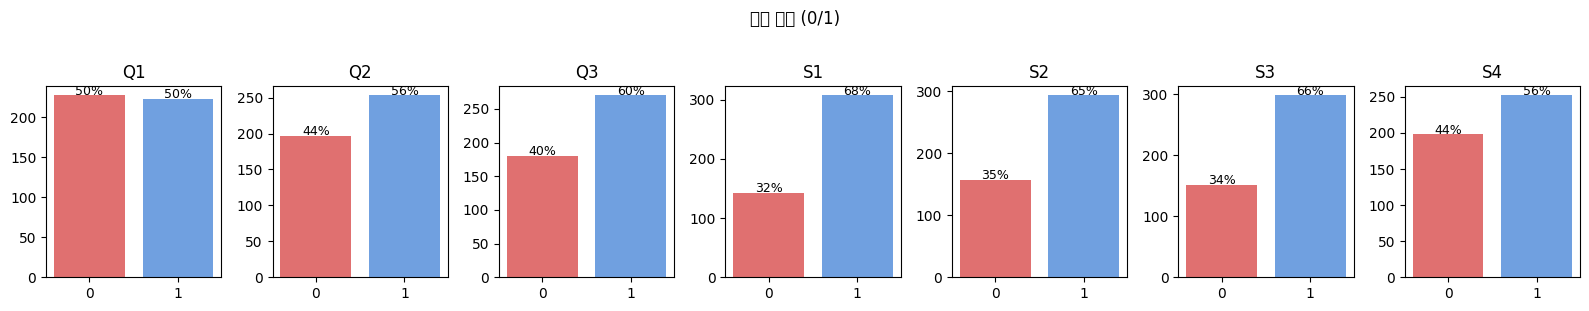

In [5]:
fig, axes = plt.subplots(1, 7, figsize=(16, 3))
for i, col in enumerate(TARGETS):
    vc = train[col].value_counts().sort_index()
    axes[i].bar(vc.index, vc.values, color=["#e07070","#70a0e0"])
    axes[i].set_title(col)
    axes[i].set_xticks([0,1])
    for v, c in zip(vc.index, vc.values):
        axes[i].text(v, c+1, f"{c/len(train)*100:.0f}%", ha="center", fontsize=9)
plt.suptitle("타겟 분포 (0/1)", y=1.02)
plt.tight_layout(); plt.show()

/tmp/ipykernel_9586/1576092224.py:6: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/1576092224.py:6: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/1576092224.py:6: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/1576092224.py:6: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/1576092224.py:6: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9586/1576092224.py:6: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout(); plt.show()
/home/rlawk/miniconda3/envs/etri/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

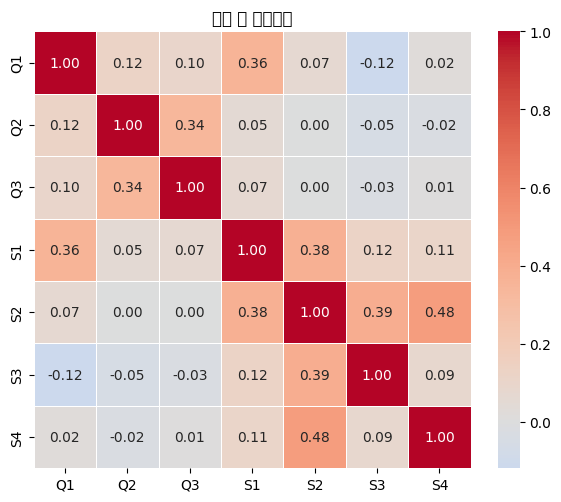

In [6]:
corr = train[TARGETS].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("타겟 간 상관관계")
plt.tight_layout(); plt.show()

In [7]:
sensor_files = sorted(SENSOR_DIR.glob("*.parquet"))
for f in sensor_files:
    df = pd.read_parquet(f)
    print(f"\n{'='*40}")
    print(f"[{f.stem}]  shape: {df.shape}")
    print(f"  columns: {list(df.columns)}")
    print(f"  dtypes:\n{df.dtypes.to_string()}")
    print(df.head(2).to_string())


[ch2025_mACStatus]  shape: (939896, 3)
  columns: ['subject_id', 'timestamp', 'm_charging']
  dtypes:
subject_id            object
timestamp     datetime64[ns]
m_charging             int64
  subject_id           timestamp  m_charging
0       id01 2024-06-26 12:03:00           0
1       id01 2024-06-26 12:04:00           0

[ch2025_mActivity]  shape: (961062, 3)
  columns: ['subject_id', 'timestamp', 'm_activity']
  dtypes:
subject_id            object
timestamp     datetime64[ns]
m_activity             int64
  subject_id           timestamp  m_activity
0       id01 2024-06-26 12:03:00           4
1       id01 2024-06-26 12:04:00           0

[ch2025_mAmbience]  shape: (476577, 3)
  columns: ['subject_id', 'timestamp', 'm_ambience']
  dtypes:
subject_id            object
timestamp     datetime64[ns]
m_ambience            object
  subject_id           timestamp                                                                                                                                

In [8]:
import ast

SENSOR_DIR = Path("/mnt/c/etri-lifelog/data/raw/data/ch2025_data_items")

def load_simple_sensor(fname, value_col):
    """단순 수치 센서 → 일별 집계"""
    df = pd.read_parquet(SENSOR_DIR / fname)
    df["date"] = df["timestamp"].dt.date.astype(str)
    agg = df.groupby(["subject_id","date"])[value_col].agg(
        ["mean","std","min","max","count"]
    ).reset_index()
    agg.columns = ["subject_id","lifelog_date"] + [f"{value_col}_{s}" for s in ["mean","std","min","max","count"]]
    return agg

# 워치 심박수 (리스트 → 먼저 펼치기)
def load_hr():
    df = pd.read_parquet(SENSOR_DIR / "ch2025_wHr.parquet")
    df["heart_rate"] = df["heart_rate"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    df = df.explode("heart_rate")
    df["heart_rate"] = pd.to_numeric(df["heart_rate"], errors="coerce")
    df["date"] = df["timestamp"].dt.date.astype(str)
    agg = df.groupby(["subject_id","date"])["heart_rate"].agg(
        ["mean","std","min","max"]
    ).reset_index()
    agg.columns = ["subject_id","lifelog_date","hr_mean","hr_std","hr_min","hr_max"]
    return agg

# 워치 만보기
def load_pedo():
    df = pd.read_parquet(SENSOR_DIR / "ch2025_wPedo.parquet")
    df["date"] = df["timestamp"].dt.date.astype(str)
    agg = df.groupby(["subject_id","date"]).agg(
        step_sum=("step","sum"),
        step_mean=("step","mean"),
        distance_sum=("distance","sum"),
        speed_mean=("speed","mean"),
        calories_sum=("burned_calories","sum"),
        running_sum=("running_step","sum"),
    ).reset_index()
    agg.rename(columns={"date":"lifelog_date"}, inplace=True)
    return agg

# 실행
feat_ac     = load_simple_sensor("ch2025_mACStatus.parquet",    "m_charging")
feat_act    = load_simple_sensor("ch2025_mActivity.parquet",    "m_activity")
feat_light  = load_simple_sensor("ch2025_mLight.parquet",       "m_light")
feat_screen = load_simple_sensor("ch2025_mScreenStatus.parquet","m_screen_use")
feat_wlight = load_simple_sensor("ch2025_wLight.parquet",       "w_light")
feat_hr     = load_hr()
feat_pedo   = load_pedo()

print("각 피처 shape:")
for name, df in [("ac",feat_ac),("activity",feat_act),("light",feat_light),
                 ("screen",feat_screen),("wlight",feat_wlight),
                 ("hr",feat_hr),("pedo",feat_pedo)]:
    print(f"  {name}: {df.shape}")

각 피처 shape:
  ac: (700, 7)
  activity: (700, 7)
  light: (700, 7)
  screen: (700, 7)
  wlight: (664, 7)
  hr: (636, 6)
  pedo: (653, 8)


In [9]:
from functools import reduce

train["lifelog_date"] = train["lifelog_date"].astype(str)

feats = [feat_ac, feat_act, feat_light, feat_screen, feat_wlight, feat_hr, feat_pedo]
feat_all = reduce(lambda a,b: pd.merge(a, b, on=["subject_id","lifelog_date"], how="left"), feats)

df = train.merge(feat_all, on=["subject_id","lifelog_date"], how="left")

print(f"최종 shape: {df.shape}")
print(f"피처 수: {df.shape[1] - len(TARGETS) - 3}")  # id/date 컬럼 제외
print(f"\n결측률 상위 10개:")
print((df.isnull().mean() * 100).sort_values(ascending=False).head(10).round(1))

최종 shape: (450, 45)
피처 수: 35

결측률 상위 10개:
hr_std          13.6
hr_max          13.1
hr_mean         13.1
hr_min          13.1
distance_sum    10.2
step_mean       10.2
step_sum        10.2
speed_mean      10.2
running_sum     10.2
calories_sum    10.2
dtype: float64


In [10]:
# 결측 처리
df_model = df.copy()
df_model["lifelog_date"] = pd.to_datetime(df_model["lifelog_date"])
df_model = df_model.fillna(0)

# subject별 시간순 split (train 마지막 10일 → validation)
val_rows = df_model.groupby("subject_id").apply(
    lambda x: x.nlargest(10, "lifelog_date")
).index.get_level_values(1)

train_df = df_model.drop(index=val_rows)
val_df   = df_model.loc[val_rows]

FEATURE_COLS = [c for c in df_model.columns 
                if c not in TARGETS + ["subject_id","sleep_date","lifelog_date"]]

X_tr  = train_df[FEATURE_COLS]
X_val = val_df[FEATURE_COLS]

print(f"train: {X_tr.shape}, val: {X_val.shape}")
print(f"피처 목록: {FEATURE_COLS}")

train: (350, 35), val: (100, 35)
피처 목록: ['m_charging_mean', 'm_charging_std', 'm_charging_min', 'm_charging_max', 'm_charging_count', 'm_activity_mean', 'm_activity_std', 'm_activity_min', 'm_activity_max', 'm_activity_count', 'm_light_mean', 'm_light_std', 'm_light_min', 'm_light_max', 'm_light_count', 'm_screen_use_mean', 'm_screen_use_std', 'm_screen_use_min', 'm_screen_use_max', 'm_screen_use_count', 'w_light_mean', 'w_light_std', 'w_light_min', 'w_light_max', 'w_light_count', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'step_sum', 'step_mean', 'distance_sum', 'speed_mean', 'calories_sum', 'running_sum']


/tmp/ipykernel_9586/1746783969.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_rows = df_model.groupby("subject_id").apply(


In [11]:
import lightgbm as lgb
from sklearn.metrics import log_loss
import warnings
warnings.filterwarnings("ignore")

params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 10,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 300,
    "early_stopping_rounds": 30,
    "verbose": -1,
    "random_state": 42,
}

models = {}
val_preds = {}
val_losses = {}

for target in TARGETS:
    y_tr  = train_df[target]
    y_val = val_df[target]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(False)]
    )
    
    pred = model.predict_proba(X_val)[:, 1]
    loss = log_loss(y_val, pred)
    
    models[target] = model
    val_preds[target] = pred
    val_losses[target] = loss
    print(f"{target}: val log-loss = {loss:.4f}")

avg_loss = np.mean(list(val_losses.values()))
print(f"\n✅ Average Log-Loss (val): {avg_loss:.4f}")

Q1: val log-loss = 0.7037
Q2: val log-loss = 0.6719
Q3: val log-loss = 0.6521
S1: val log-loss = 0.6085
S2: val log-loss = 0.6953
S3: val log-loss = 0.6781
S4: val log-loss = 0.6788

✅ Average Log-Loss (val): 0.6698


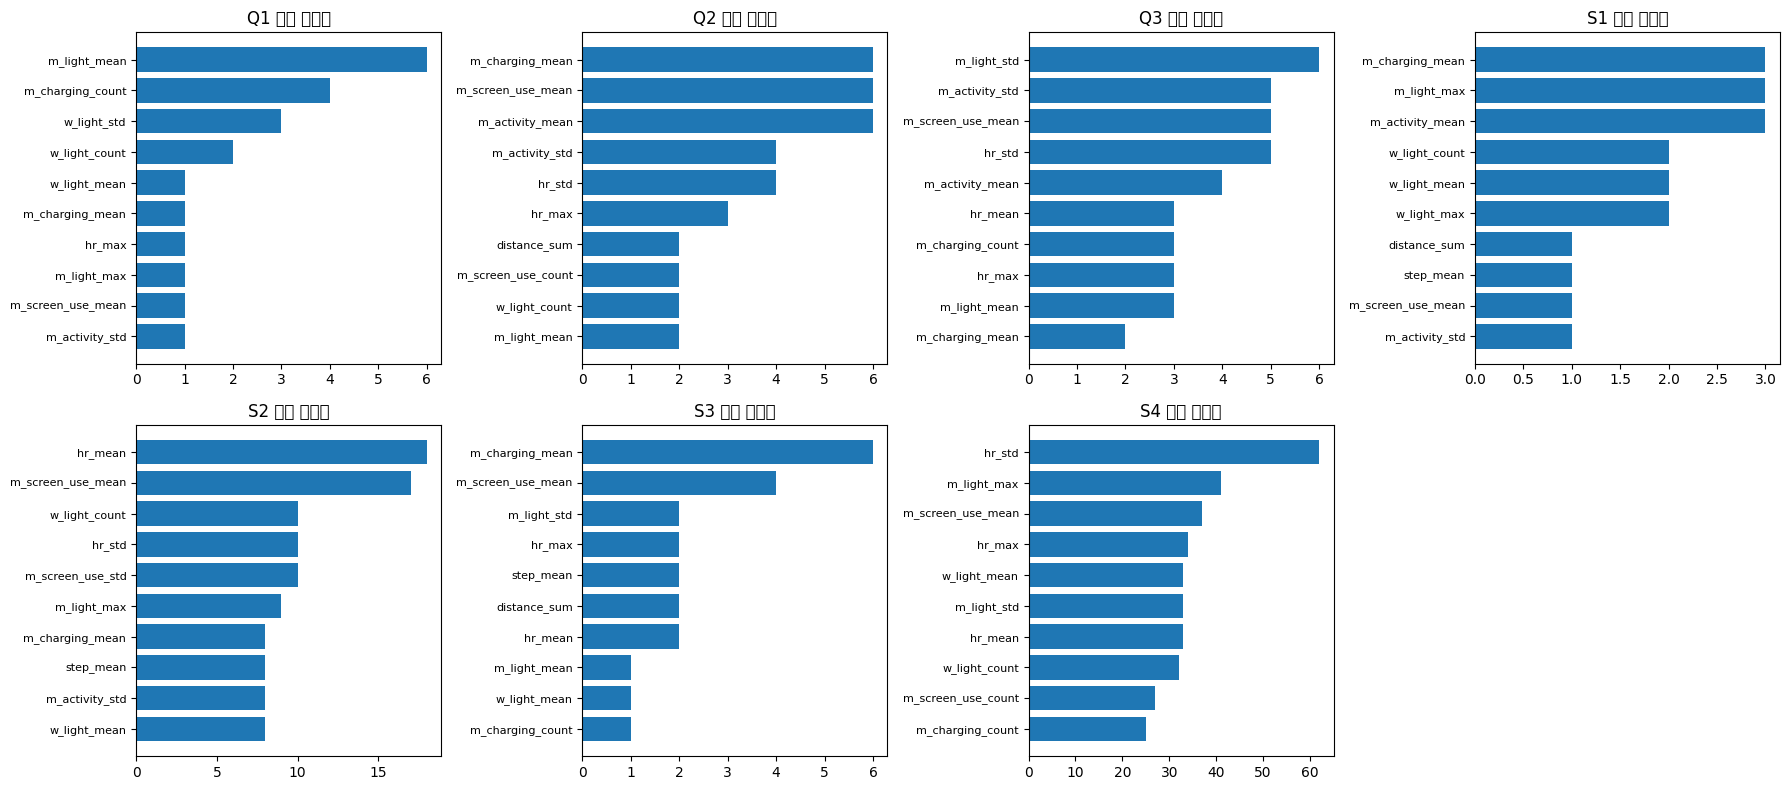

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, target in enumerate(TARGETS):
    imp = pd.Series(
        models[target].feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=False).head(10)
    
    axes[i].barh(imp.index[::-1], imp.values[::-1])
    axes[i].set_title(f"{target} 피처 중요도")
    axes[i].tick_params(axis='y', labelsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
# test 데이터에 피처 조인
sub_model = sub.copy()
sub_model["lifelog_date"] = pd.to_datetime(sub_model["lifelog_date"]).astype(str)

# feat_all은 이미 만들어진 피처 (Cell 7에서)
sub_model["lifelog_date_str"] = sub_model["lifelog_date"]
feat_all_str = feat_all.copy()
feat_all_str["lifelog_date"] = feat_all_str["lifelog_date"].astype(str)

sub_model = sub_model.merge(feat_all_str, on=["subject_id","lifelog_date"], how="left")
sub_model = sub_model.fillna(0)

X_test = sub_model[FEATURE_COLS]
print(f"test shape: {X_test.shape}")
print(f"결측: {X_test.isnull().sum().sum()}")

# 전체 train으로 재학습 후 예측
final_models = {}
for target in TARGETS:
    y_all = df_model[target]
    X_all = df_model[FEATURE_COLS]
    
    model = lgb.LGBMClassifier(**{k:v for k,v in params.items() 
                                   if k != "early_stopping_rounds"})
    model.fit(X_all, y_all)
    final_models[target] = model

# 제출 파일
submission = sub[["subject_id","sleep_date","lifelog_date"]].copy()
for target in TARGETS:
    submission[target] = final_models[target].predict_proba(X_test)[:, 1]

submission.to_csv("/mnt/c/etri-lifelog/submissions/baseline_lgbm.csv", index=False)
print("\n✅ 제출 파일 저장 완료")
print(submission.head())
print(submission[TARGETS].describe().round(3))

test shape: (250, 35)
결측: 0

✅ 제출 파일 저장 완료
  subject_id  sleep_date lifelog_date        Q1        Q2        Q3        S1  \
0       id01  2024-07-31   2024-07-30  0.166019  0.916540  0.459532  0.847603   
1       id01  2024-08-01   2024-07-31  0.027622  0.245551  0.148467  0.982153   
2       id01  2024-08-02   2024-08-01  0.007594  0.757441  0.952408  0.906163   
3       id01  2024-08-03   2024-08-02  0.202383  0.793082  0.833990  0.914506   
4       id01  2024-08-04   2024-08-03  0.993035  0.208966  0.984830  0.654667   

         S2        S3        S4  
0  0.354390  0.982636  0.623109  
1  0.997259  0.999874  0.937072  
2  0.997851  0.995190  0.933856  
3  0.914585  0.996203  0.371438  
4  0.940206  0.972586  0.807723  
            Q1       Q2       Q3       S1       S2       S3       S4
count  250.000  250.000  250.000  250.000  250.000  250.000  250.000
mean     0.500    0.628    0.737    0.783    0.690    0.754    0.624
std      0.359    0.355    0.312    0.326    0.344    0.328